# Phrase Recurrence-Scale Grouping

Resolution corpora are typically structured at several nested levels: resolutions are grouped per day, each day preceded by a recurring "resumption" formula; each resolution usually contains a single decision formula, but sometimes several, each followed by a repeated phrase. Phrases that operate at different levels of this hierarchy recur at very different, but fairly characteristic, token intervals.

This notebook demonstrates `WindowEstimator.group_by_scale`, which uses each candidate phrase's own median successive-occurrence gap to suggest groups of phrases that likely belong to the same structural level &mdash; entirely from the gap statistics, without needing to know in advance how many levels exist or which phrase belongs to which.

We apply it directly to the real resolution-paragraphs corpus used elsewhere in this documentation (`data/resolution_paragraphs/paragraphs-3823.tsv.gz`).

In [1]:
%reload_ext autoreload
%autoreload 2

import csv
import gzip
import re

import matplotlib.pyplot as plt

from formula_detection.phrase_cooccurrence import PhraseCooccurrenceIndex
from formula_detection.window_estimator import WindowEstimator

TOKEN_RE = re.compile(r"[A-Za-z\u00c0-\u00ff]+")


def tokenize(text):
    return TOKEN_RE.findall(text.lower())


rows = []
with gzip.open('data/resolution_paragraphs/paragraphs-3823.tsv.gz', 'rt', encoding='utf-8') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        rows.append(row)

flat_stream = []
for row in rows:
    flat_stream.extend(tokenize(row['text']))

print(f'{len(rows)} paragraphs, {len(flat_stream)} tokens')

2909 paragraphs, 449905 tokens


## 1. Candidate phrases for the suspected structural levels

Based on the corpus's known structure:

* **Day level** &mdash; each day's resolutions open with a Latin weekday name ("Luna den ..." = Monday, "Mercurii den ..." = Wednesday, etc.). We treat any of the six weekday openers as one merged "resumption" signal, since each individual weekday name only covers about a sixth of days.
* **Resolution/decision level** &mdash; the decision formula (*"waar op gedelibereert zynde is goedgevonden"*) and its immediate restatement (*"is goedgevonden en verstaan dat"*), which together mark a single decision.
* An additional candidate, the missive-receipt opener (*"ontfangen een missive van"*), to see where the method places a phrase we have *not* pre-classified by hand.

In [2]:
day_names = ['luna den', 'martis den', 'mercurii den', 'jovis den', 'veneris den', 'sabbathi den']
candidate_phrases = day_names + [
    'waar op gedelibereert zynde is goedgevonden',
    'is goedgevonden en verstaan dat',
    'ontfangen een missive van',
]

cooc_index = PhraseCooccurrenceIndex(candidate_phrases, windows=[50])
cooc_index.index_stream(flat_stream)

# Merge the six weekday-opener variants into one "resumption" position list.
resumption_positions = sorted(
    pos for day_name in day_names for pos in cooc_index.phrase_positions.get(day_name, [])
)

phrase_positions = {
    'resumption (day opener)': resumption_positions,
    'decision formula': cooc_index.phrase_positions['waar op gedelibereert zynde is goedgevonden'],
    'decision restatement': cooc_index.phrase_positions['is goedgevonden en verstaan dat'],
    'missive opener': cooc_index.phrase_positions['ontfangen een missive van'],
}

for phrase, positions in phrase_positions.items():
    print(f'  {phrase: <25}{len(positions)} occurrences')

  resumption (day opener)  260 occurrences
  decision formula         836 occurrences
  decision restatement     730 occurrences
  missive opener           1267 occurrences


## 2. Per-phrase recurrence-gap statistics

In [3]:
estimator = WindowEstimator(phrase_positions)
for phrase in phrase_positions:
    print(estimator.phrase_stats(phrase))

PhraseWindowStats(phrase='resumption (day opener)', n_occurrences=260, knee=2978, median_gap=1398, multimodal=True)
PhraseWindowStats(phrase='decision formula', n_occurrences=836, knee=1315, median_gap=391, multimodal=True)
PhraseWindowStats(phrase='decision restatement', n_occurrences=730, knee=1328, median_gap=469, multimodal=True)
PhraseWindowStats(phrase='missive opener', n_occurrences=1267, knee=1259, median_gap=64.0, multimodal=True)


`median_gap` is the characteristic recurrence interval for each phrase &mdash; the quantity `group_by_scale` clusters on. As expected, the day-level resumption opener has by far the largest median gap, the decision formula and its restatement are close to each other (they always occur as a pair, one decision apart), and the missive opener recurs much more often &mdash; a sign that it operates at a *sub*-resolution level here (multiple missives are often received and listed in sequence within a single resolution), rather than once per resolution as we might naively have assumed.

## 3. Visualising the gap distributions

A box plot of each phrase's full gap distribution, on a log scale, makes the separation visible directly &mdash; not just as a single median number.

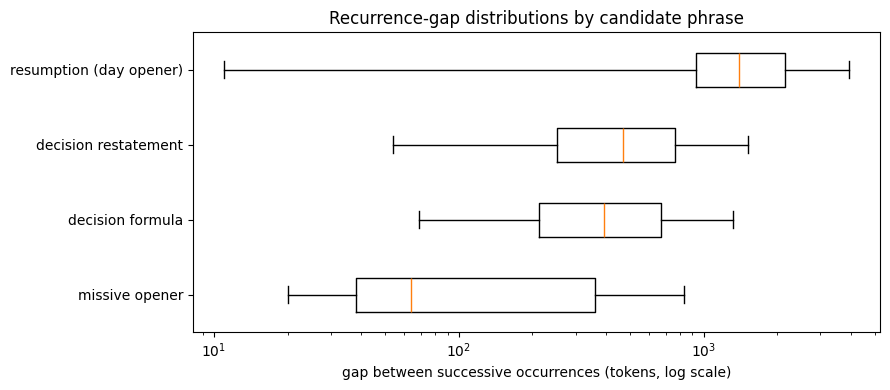

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

labels = list(phrase_positions.keys())
gap_lists = [estimator.phrase_stats(p).gaps for p in labels]

# order by median gap so the plot reads bottom-to-top as small-to-large scale
order = sorted(range(len(labels)), key=lambda i: estimator.phrase_stats(labels[i]).median_gap)
labels = [labels[i] for i in order]
gap_lists = [gap_lists[i] for i in order]

ax.boxplot(gap_lists, vert=False, tick_labels=labels, showfliers=False)
ax.set_xscale('log')
ax.set_xlabel('gap between successive occurrences (tokens, log scale)')
ax.set_title('Recurrence-gap distributions by candidate phrase')
plt.tight_layout()
plt.show()

## 4. Suggested groups

`group_by_scale` sorts phrases by `log10(median_gap)` and splits wherever the gap between consecutive phrases' scales exceeds `log_gap_threshold`. The default (`0.5`, a factor of about 3.2x) is a reasonable starting point, but on real, noisier data the right threshold for separating *all* the levels you care about may need a small adjustment &mdash; shown here for both the default and a slightly stricter value.

In [5]:
for threshold in (0.5, 0.4):
    groups = estimator.group_by_scale(min_occurrences=3, log_gap_threshold=threshold)
    print(f'log_gap_threshold={threshold}: {groups}')
    for group in groups.groups:
        print(f'  {group}  ->  {group.phrases}')
    print()

log_gap_threshold=0.5: ScaleGroups(n_groups=2, median_scales=[64, 469], n_excluded=0)
  ScaleGroup(group_id=0, median_scale=64.0, n_phrases=1)  ->  ['missive opener']
  ScaleGroup(group_id=1, median_scale=469.0, n_phrases=3)  ->  ['decision formula', 'decision restatement', 'resumption (day opener)']

log_gap_threshold=0.4: ScaleGroups(n_groups=3, median_scales=[64, 428, 1398], n_excluded=0)
  ScaleGroup(group_id=0, median_scale=64.0, n_phrases=1)  ->  ['missive opener']
  ScaleGroup(group_id=1, median_scale=428.2, n_phrases=2)  ->  ['decision formula', 'decision restatement']
  ScaleGroup(group_id=2, median_scale=1398.0, n_phrases=1)  ->  ['resumption (day opener)']



At the default threshold, the decision-level pair and the day-level opener end up in the same group &mdash; their median gaps (about 430 and 1400 tokens) are only a factor of ~3.3 apart, just over the default's factor-of-~3.2 cutoff in the other direction. Lowering the threshold slightly to `0.4` separates all three intended levels cleanly: the missive opener (sub-resolution scale), the decision formula and its restatement (resolution scale), and the day-opener (day scale).

This is a realistic illustration of using the tool in practice: the suggested groups are a strong, well-motivated starting point grounded directly in the corpus's own statistics, but on real (as opposed to synthetic) data the threshold is still worth a quick visual sanity check against the box plot above rather than trusting the default blindly &mdash; consistent with the broader lesson in [Document-Pattern-Detection-Findings.md](Document-Pattern-Detection-Findings.md) that automatically-chosen thresholds need verification on real corpora.